# Tutorial for the Analysis of MERFISH Data from the MERSCOPE Platform

This tutorial demonstrates how to analyze **MERFISH** spatial transcriptomics data from the Vizgen MERSCOPE platform using the [SPArrOW](https://sparrow-pipeline.readthedocs.io) pipeline.

**What you will learn:**
- How to read MERSCOPE output data into a `SpatialData` object
- How to preprocess fluorescence images (min-max filtering, contrast enhancement)
- How to segment cells using Cellpose and allocate transcripts to obtain a gene-by-cell matrix
- How to normalize the count matrix and perform Leiden clustering

**Dataset:** [Mouse liver (Liver1Slice1)](https://info.vizgen.com/mouse-liver-data) from Vizgen (accessed 2024-01-10)

### Scope of this notebook

This tutorial is **modality-specific**: it focuses on data loading, visualization, and conversion to a gene-by-cell table via platform-specific preprocessing and segmentation for MERSCOPE data.

By the end of this notebook, you will have:
- Loaded MERSCOPE data into a `SpatialData` object
- Explored platform-specific data representations
- Preprocessed the image and segmented cells with Cellpose
- Generated a gene-by-cell count matrix and performed Leiden clustering

To avoid duplicating shared downstream analysis across multiple tutorials, we stop after clustering and continue with the canonical end-to-end workflow in **SPArrOW: How to start**.

### Installation

```bash
uv venv .venv_sparrow --python=3.12
source .venv_sparrow/bin/activate
uv pip install -e .
uv pip install jupyter
uv pip install rioxarray
uv pip install cellpose==3.1.1.1
uv pip install dask-cuda==24.12.0
uv pip install bokeh
```

**Should be removed if already present in the environment**
bokeh, dask-cuda, rioxarray not present!!!


### Package imports

In [1]:
# lets you automatically reload modules when their source code changes
%load_ext autoreload
# reload all modules (except those excluded by %aimport) every time before executing the Python code
%autoreload 2
# allows you to display matplotlib plots directly in the notebook
%matplotlib inline

In [ ]:
import os
import tempfile

import matplotlib as mpl
import matplotlib.pyplot as plt
import scanpy as sc
import sparrow as sp
import spatialdata as sd
from sparrow.datasets.registry import get_registry

### Plotting configurations

In [3]:
font_size = 8
plot_dpi = 250
save_dpi = 500
# Setting fonts, line widths, and figure resolution for all plots in this tutorial:
mpl.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": font_size + 3,
    "axes.titleweight": "bold",
    "axes.labelsize": font_size,
    "xtick.labelsize": font_size,
    "ytick.labelsize": font_size,
    "lines.linewidth": 1.5,
    "figure.dpi": plot_dpi,
})

### Download the data

The first step of the SPArrOW pipeline includes reading in the raw data. The example dataset for this notebook will be downloaded and cached using `pooch` via `sparrow.dataset.registry`. It is the mouse liver public dataset from vizgen.

In [ ]:
registry = get_registry()
_ = registry.fetch("transcriptomics/vizgen/mouse/Liver1Slice1/images/mosaic_DAPI_z3.tif")
_ = registry.fetch("transcriptomics/vizgen/mouse/Liver1Slice1/images/mosaic_PolyT_z3.tif")
_ = registry.fetch("transcriptomics/vizgen/mouse/Liver1Slice1/images/micron_to_mosaic_pixel_transform.csv")
path_transcripts = registry.fetch("transcriptomics/vizgen/mouse/Liver1Slice1/detected_transcripts.csv")

### Specifying paths

In [10]:
# Directory where the spatialdata .zarr will be saved
# You can change this to any directory you prefer; using a temporary directory is convenient for testing
OUTPUT_DIR = tempfile.gettempdir()
output_path = os.path.join(OUTPUT_DIR, "sdata_merscope.zarr")

## Create the SpatialData object

For the creation of a spatial data object we will use the MERSCOPE-specific reader via sp.io.merscope to import the fluorescence images and detected transcripts. The output is written to a Zarr store on disk so large spatial data can be handled efficiently. Beware as this step can take around 10 minutes!

In [ ]:
# Derive the input path from the downloaded transcript file location
input_path = os.path.dirname(path_transcripts)

# Load the MERSCOPE dataset into a SpatialData object
sdata = sp.io.merscope(
    path=input_path,
    to_coordinate_system="global",
    z_layers=[
        3,
    ],
    backend=None,
    transcripts=True,
    mosaic_images=True,
    do_3D=False,
    z_projection=False,
    image_models_kwargs={"scale_factors": None},
    output=None,
    filter_gene_names=["blank"]
)

In [ ]:
# Save the SpatialData object to a .zarr file and read it back in to ensure that the data is correctly written and can be accessed without issues.
sdata.write(output_path, overwrite=True)
sdata = sd.read_zarr(output_path)

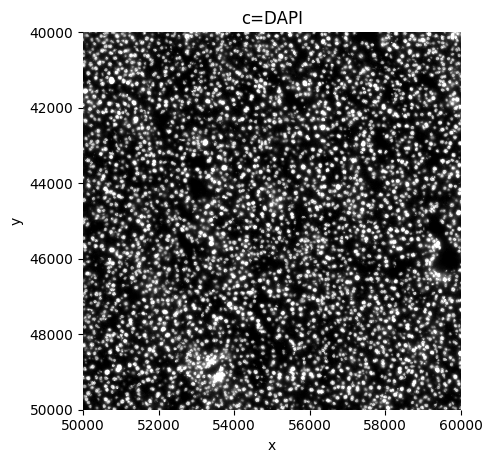

In [ ]:
# Specify the coordinates for the region of interest (ROI) in the format [x_min, x_max, y_min, y_max]
coordinates = [50000, 60000, 40000, 50000]

sp.pl.plot_shapes(
    sdata,
    img_layer=["mouse_Liver1Slice1_z3_global"],
    crd=coordinates,
    channel="DAPI",
    figsize=(8, 8),
    fig_kwargs={"dpi": plot_dpi},
)

## 2. Processing the image(s)

### 2.1 Min-max filtering and contrast enhancing
The second step of preprocessing the data includes a couple of steps:


- A min-max filter can be added. The goal of this function is to subtract background noise, and make the borders of the nuclei/cells cleaner, plus it will delete the occasional debris. If you take the size too small, smaller than the size of your nuclei, the function will create donuts, with black spots in the center of your cells.  If the size of the min-max filter is chosen too big, not enough background is subtracted, so a tradeoff should be made. This might need some finetuning. Bigger for whole cells. Adapt this parameter to make sure you delete debris and HALO's. 

- We recommend to perform contrast enhancing on your image. SPArrOW does this by using histogram equalization (CLAHE function). The amount of correction needed can be decided by adapting the contrast_clip value. If the image is already quite bright, 3.5 might be a good starting value. For dark images, you can go up to 10 or even more. Make sure at the end the whole image is evenly illuminated and no cells are dark in the background.

In every cleaning step, a new image is created and written to disk, that is then used as an input for the next step.

In [ ]:
sdata=sp.im.min_max_filtering(
    sdata,
    img_layer="mouse_Liver1Slice1_z3_global",
    output_layer="min_max_filtered",
    size_min_max_filter=[85, 135],
    crd=coordinates,
    overwrite=True,
    )
sdata=sp.im.enhance_contrast(
    sdata,
    img_layer="min_max_filtered",
    output_layer="clahe",
    contrast_clip=[13.5, 18.5],
    crd=coordinates,
    overwrite=True,
    )

2026-01-16 08:56:54,044 - sparrow.image._map - INFO - 'combine_z' is False, but not all 'z-slices' spefified in 'fn_kwargs'/'func' ({np.str_('DAPI'): {'size_min_max_filter': 85}, np.str_('PolyT'): {'size_min_max_filter': 135}}/{np.str_('DAPI'): <function min_max_filtering.<locals>._apply_min_max_filter at 0x7ff1282b8c20>, np.str_('PolyT'): <function min_max_filtering.<locals>._apply_min_max_filter at 0x7ff1282b8c20>}). Specifying z-slices ([0]).
2026-01-16 08:56:54,098 - sparrow.image._manager - INFO - Writing results to layer 'min_max_filtered'
2026-01-16 08:56:58,251 - sparrow.utils._io - WARNING - layer with name 'min_max_filtered' already exists. Overwriting...
2026-01-16 08:57:01,522 - sparrow.image._map - INFO - 'combine_z' is False, but not all 'z-slices' spefified in 'fn_kwargs'/'func' ({np.str_('DAPI'): {'contrast_clip': 13.5}, np.str_('PolyT'): {'contrast_clip': 18.5}}/{np.str_('DAPI'): <function enhance_contrast.<locals>._apply_clahe at 0x7ff13045ad40>, np.str_('PolyT'): <fu

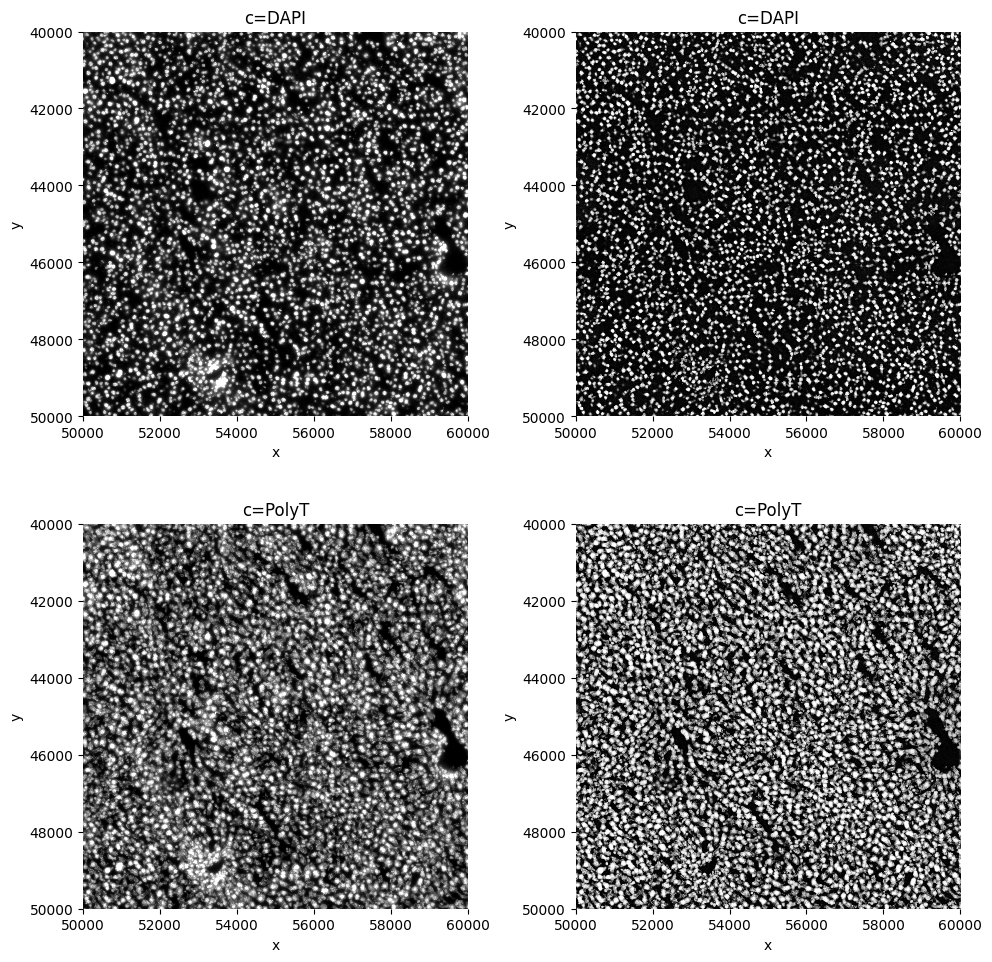

In [ ]:
sp.pl.plot_shapes(
    sdata,
    img_layer=["mouse_Liver1Slice1_z3_global", "clahe"],
    crd=coordinates,
    figsize=(10, 10),
    fig_kwargs={"dpi": plot_dpi},
)

## 3. Segmenting the image

For the segmentation, we here show an example on how to use Cellpose, a deep learning network based on a UNET architecture. This is a great tool, because it can segment both nuclei and whole cells. 

*There are some parameters that need to be specified for the segmentation function:*
| Parameter | Default Value | Meaning |
|---|---|---|
| `model` | `cellpose_callable` | he segmentation model function used to process the images. Callable should take as input numpy arrays of dimension (z,y,x,c) and return labels of dimension (z,y,x,c). It can have an arbitrary number of other parameters. |
| `depth` | `100` | The depth in y and x dimension. The depth parameter is passed to dask.array.map_overlap. If trim is set to False, it’s recommended to set the depth to a value greater than twice the estimated diameter of the cells/nulcei. |
| `chunks` | `None` | Chunk sizes for processing. Can be a string, integer or tuple of integers. If chunks is a tuple, they contain the chunk size that will be used in y and x dimension. |

*Multiple key parameters need to be given as an input to the Cellpose algorithm. We recommend tuning for the optimal segmentation quality.*
| Parameter | Default Value | Meaning |
|---|---|---|
| `batch_size` | `8` | Number of 256x256 (cellpose>=4.0) or 224x224 (cellpose<4.0) patches to run simultaneously. (can make smaller or bigger depending on GPU/CPU/MPS memory usage). |
| `diameter` | `15` | Expected an estimate of the diameter of a nucleus in pixels. If put to none, Cellpose will do the estimation by himself, but this estimation might take longer than the actual segmentation, and if often far off. This of course is tissue and method dependent. You can run the algorithm on a small piece (I[0:1000,0:1000] for example), to get an estimate of the size. However, this estimate isn't always accurate. So check the quality at the end. If you see all nuclei/cells are estimated too small, enlarge this parameter. |
| `flow_threshold` | `0.4` | Specifies the maximum allowed error of the shape flows for each mask. If you increase it, more masks with less round shapes will be accepted. Lower it if cellpose is returning too many ill-shaped ROIs, up it if you miss non-round shaped cells. A recommended range is 0.6 and 0.95, depending on the cell shapes. |
| `cellprob_threshold` | `0.0` | Indicates how many of the possible masks are kept. Making it smaller (up to -6), will give you more masks, bigger is less masks (up to 0). Be careful, you can oversegment so always check the quality |
| `min_size` | `80` | The minimum size (in pixels) of segmented objects. Objects smaller than this will be excluded. |
| `pretrained_model` | `"nuclei"` | A pretrained Cellpose model to use for segmentation. This can either be a model type, e.g. `"nuclei"`, `"cyto"`, `"cyto3"` for Cellpose<4.0 or `"cpsam"` for Cellpose >=4.0; or a file path to a saved model on disk. |
| `device` | `None` | Defines the device you want to work on, if you only have cpu, you can skip this input parameter. If only having CPU, please tune the parameters on a small subset, and then make it to the big one. This might take a while for large images, but it should work. Can be `"cpu"`, `"cuda"`, `"mps"`, or another supported device. If None, device will be automatically inferred, i.e. is `"cuda"` or `"mps"` if available, otherwise `"cpu"`. |

Here, the parameter is set to `cuda` in order for the segmentation algorithm to be executed on the GPU. This allows us to speed up the segmentation process considerably. For this to work the virtual environment should contain the torch module which is part of the 'testing' optional dependencies. Our full image dimension is 21000 x 21000 pixels so even a GPU, the segmentation process will still take some time.

In [ ]:
%%time
# Get the channel names from the clahe image layer to set Cellpose channel indices
clahe_channels = sdata["clahe"].c.data.tolist()

sdata = sp.im.segment(
    sdata,
    img_layer="clahe",
    depth=200,
    model=sp.im.cellpose_callable,
    # Parameters passed to the cellpose callable:
    pretrained_model="cyto3",
    device="cuda",
    diameter=100,
    flow_threshold=0.85,
    cellprob_threshold=-4,
    channels=[clahe_channels.index("PolyT") + 1, clahe_channels.index("DAPI") + 1],
    output_labels_layer="segmentation_mask_crop",
    output_shapes_layer="segmentation_mask_boundaries_crop",
    crd=coordinates,
    chunks=4096,
    overwrite=True,
)

/data/groups/technologies/spatial.catalyst/Arne/napari-sparrow/.venv_sparrow_merscope/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
2026-01-16 09:00:06,666 - sparrow.image._tiling - WARNING - 'jax' or 'basicpy' not installed, to use 'sparrow.im.tiling_correction', please install these libraries.
2026-01-16 09:00:06,666 - sparrow.image._tiling - WARNING - 'squidpy' not installed, to use 'sparrow.im.tiling_correction' please install this library.
2026-01-16 09:00:10,835 - sparrow.plot._enrichment - WARNING - 'squidpy' not installed, to use 'sparrow.pl.nhood_enrichment' please install this library.
2026-01-16 09:00:12,001 - sparrow.plot._qc_cells - WARNING - 'joypy' not ins

/data/groups/technologies/spatial.catalyst/Arne/napari-sparrow/.venv_sparrow_merscope/lib/python3.12/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/data/groups/technologies/spatial.catalyst/Arne/napari-sparrow/.venv_sparrow_merscope/lib/python3.12/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


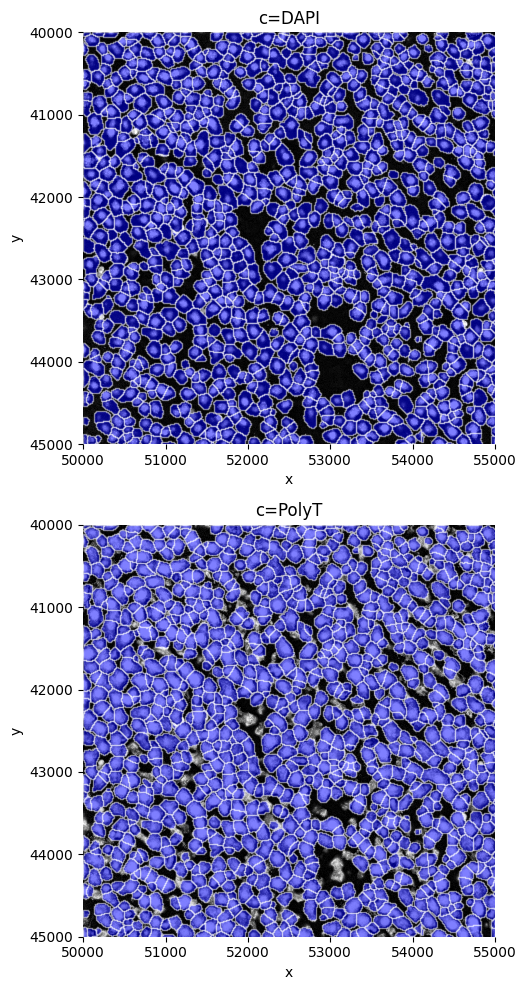

In [ ]:
# Specify the coordinates for the cropped region of interest (ROI) in the format [x_min, x_max, y_min, y_max]
cropped_coordinates = [50000, 55000, 40000, 45000]

sp.pl.plot_shapes(
    sdata,
    shapes_layer="segmentation_mask_boundaries_crop",
    img_layer=["clahe"],
    crd=cropped_coordinates,
    figsize=(10, 10),
    fig_kwargs={"dpi": plot_dpi},
)

## 4. Create the AnnData table

In [ ]:
sdata = sp.tb.allocate(
    sdata=sdata,
    labels_layer="segmentation_mask_crop",
    points_layer="transcripts_global",
    output_layer="table_transcriptomics_crop",
    update_shapes_layers=False,
    overwrite=True,
)

2026-01-16 09:03:53,948 - sparrow.table._allocation - INFO - Calculating cell counts.
/home/VIB.LOCAL/arne.defauw/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
2026-01-16 09:04:42,579 - sparrow.utils._io - WARNING - layer with name 'table_transcriptomics_crop' already exists. Overwriting...


2026-01-16 09:05:09,538 - sparrow.plot._sanity - INFO - Plotting 1 transcripts.
2026-01-16 09:05:09,544 - sparrow.plot._sanity - INFO - Selecting boundaries
/data/groups/technologies/spatial.catalyst/Arne/napari-sparrow/.venv_sparrow_merscope/lib/python3.12/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/data/groups/technologies/spatial.catalyst/Arne/napari-sparrow/.venv_sparrow_merscope/lib/python3.12/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/st

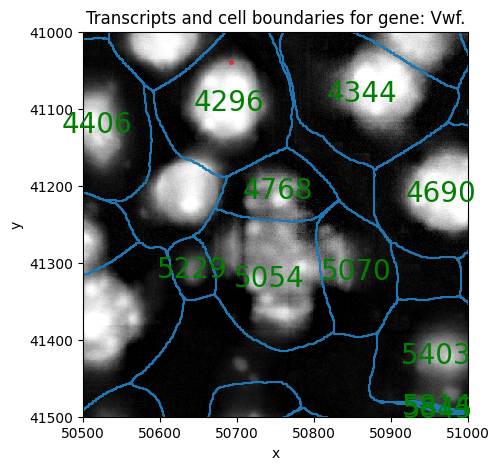

In [ ]:
sp.pl.sanity(
    sdata,
    img_layer="clahe",
    shapes_layer = "segmentation_mask_boundaries_crop",
    points_layer= "transcripts_global",
    plot_cell_number=True,
    gene="Vwf",
    crd = [50000, 51000, 41000, 42000],
    figsize=(5,5),
)

In [ ]:
# Look-up a the number of transcripts for the Vwf gene in a cell shown above (using the cell ID),
# it should be the same number as transcripts plotted above.
sdata["table_transcriptomics_crop"][sdata["table_transcriptomics_crop"].obs["cell_ID"] == 4296].to_df()["Vwf"]

cells
4296_segmentation_mask_crop_e0acaceb    1
Name: Vwf, dtype: uint32

## Visualize gene expression

/data/groups/technologies/spatial.catalyst/Arne/napari-sparrow/.venv_sparrow_merscope/lib/python3.12/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
2026-01-16 09:05:37,732 - sparrow.plot._plot - WARNING - There are '2' cells in provided shapes_layer 'segmentation_mask_boundaries_crop' not found in 'sdata.tables[table_transcriptomics_crop]' (linked through 'cell_ID'), these cells will not be plotted.
/data/groups/technologies/spatial.catalyst/Arne/napari-sparrow/.venv_sparrow_merscope/lib/python3.12/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

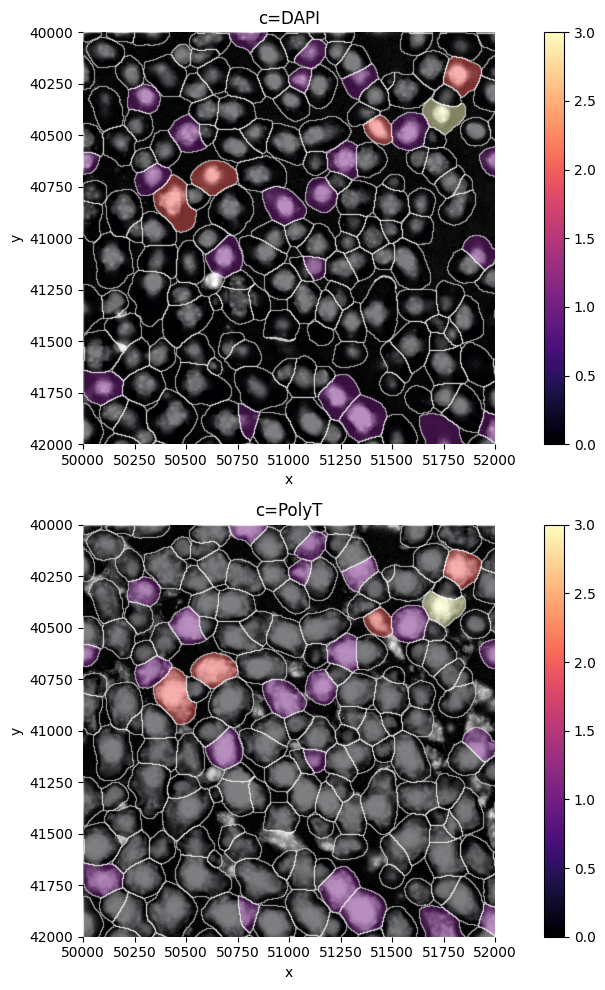

In [ ]:
sp.pl.plot_shapes(
    sdata,
    img_layer="clahe",
    shapes_layer="segmentation_mask_boundaries_crop",
    figsize=(10, 10),
    crd=cropped_coordinates,
    table_layer="table_transcriptomics_crop",
    column="Vwf",
    fig_kwargs={"dpi": plot_dpi},
)

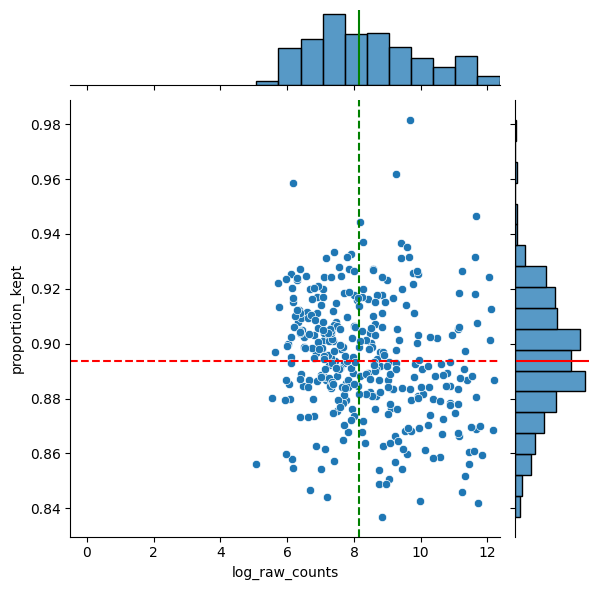

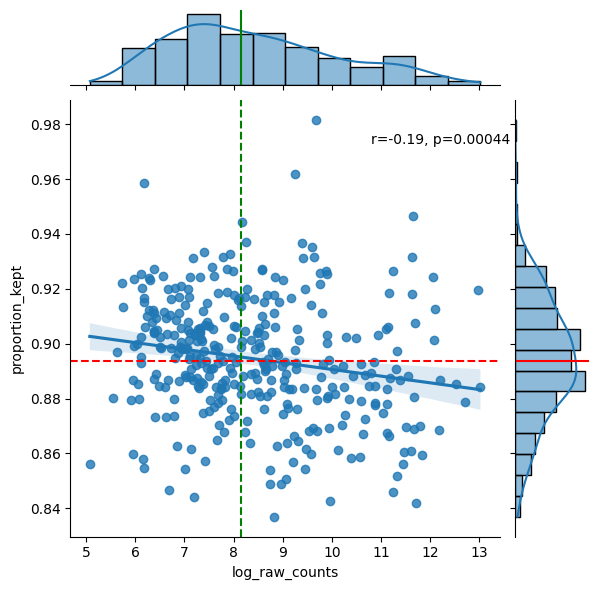

2026-01-16 09:06:02,247 - sparrow.plot._transcripts - INFO - The ten genes with the highest proportion of transcripts filtered out in the region of interest ([x_min,x_max,y_min,y_max]=(50000, 60000, 40000, 50000)):
        proportion_kept  raw_counts
Lhfp           0.836944        6832
Cald1          0.841919      121457
Sdc3           0.842543       21301
Nes            0.843961        1333
Eif3a          0.846109       76983
Cxcl14         0.846535         808
Adgre1         0.848811        6310
Laptm5         0.848979        7787
Eif3f          0.850541        8591
Pabpc1         0.851871       82563


In [ ]:
df = sp.pl.analyse_genes_left_out(
    sdata,
    labels_layer="segmentation_mask_crop",
    table_layer="table_transcriptomics_crop",
    points_layer="transcripts_global",
)

## Preprocess the AnnData table

In [ ]:
# Perform preprocessing
sdata = sp.tb.preprocess_transcriptomics(
    sdata,
    labels_layer="segmentation_mask_crop",
    table_layer="table_transcriptomics_crop",
    output_layer="table_transcriptomics_preprocessed_crop",  # write results to a new slot, we could also write to the same slot (when passing overwrite==True).
    min_counts=10,
    min_cells=5,
    size_norm=True,
    n_comps=50,
    overwrite=True,
    update_shapes_layers=False,
)

2026-01-16 09:06:10,334 - sparrow.table._preprocess - INFO - Calculating cell size from provided labels_layer 'segmentation_mask_crop'
/home/VIB.LOCAL/arne.defauw/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/VIB.LOCAL/arne.defauw/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/data/groups/technologies/spatial.catalyst/Arne/napari-sparrow/.venv_sparrow_merscope/lib/python3.12/site-packages/spatialdata/models/models.py:1183: UserWarning: Converting `region_key: fov_labels` to categorical dtype.
  convert_region_column_to_categorical(adata)
2026-01-16 09:06:25,322 - sparrow.utils._io - WARNING - layer with name 'table_transcriptomics_preprocessed_crop' already exists. Overwriting...

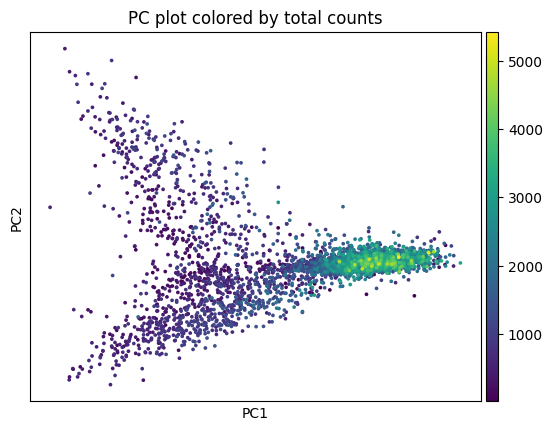

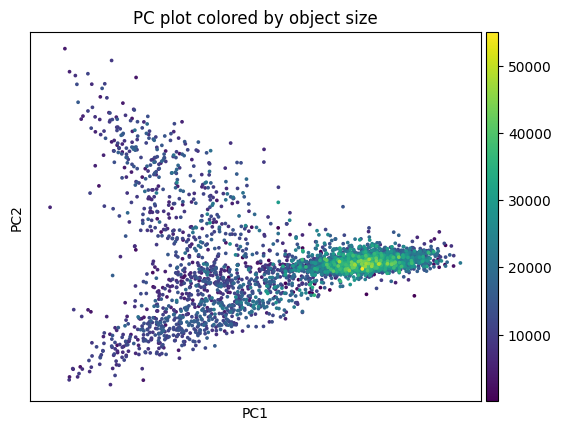

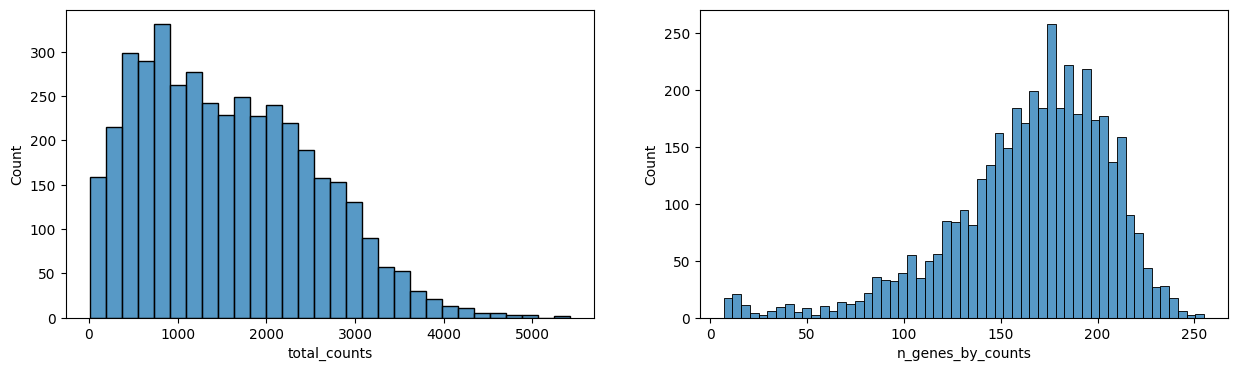

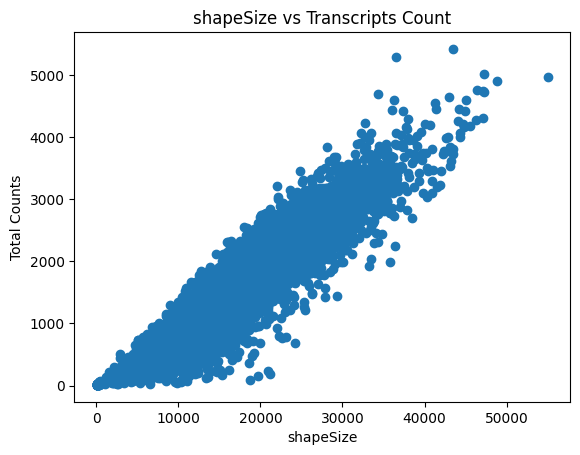

In [ ]:
sp.pl.preprocess_transcriptomics(
    sdata,
    table_layer="table_transcriptomics_preprocessed_crop",
)

In [ ]:
sdata = sp.tb.filter_on_size(
    sdata,
    labels_layer="segmentation_mask_crop",
    table_layer="table_transcriptomics_preprocessed_crop",
    output_layer="table_transcriptomics_filter_crop",
    min_size=500,
    max_size=100000,
    update_shapes_layers=False,
    overwrite=True,
)

2026-01-16 09:07:10,732 - sparrow.utils._io - WARNING - layer with name 'table_transcriptomics_filter_crop' already exists. Overwriting...
2026-01-16 09:07:25,247 - sparrow.table._table - INFO - 52 cells were filtered out based on size.


## Next steps

**You now have a fully preprocessed genes-by-cells table. The following step in the downstream analysis is clustering and is not platform-specific so you can find these steps at the [SPArrOW: How to start](https://sparrow-pipeline.readthedocs.io/en/latest/tutorials/general/SPArrOW_how_to_start.html#clustering) tutorial.**

Continue with the canonical shared workflow in **SPArrOW: How to start** for:
- Cell-type annotation using a marker gene list
- Spatial enrichment analysis
- Further downstream interpretation and visualization

Continue here: [SPArrOW: How to start](https://sparrow-pipeline.readthedocs.io/en/latest/tutorials/general/SPArrOW_how_to_start.html#clustering).